In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import (confusion_matrix, 
                           classification_report, 
                           accuracy_score,
                           precision_score,
                           recall_score)

In [28]:
df = pd.read_csv("Social_Network_Ads.csv")

In [29]:
print("Dataset head:")
print(df.head())

Dataset head:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [30]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(400, 5)


In [31]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [32]:
print("\nDataset statistics:")
print(df.describe())


Dataset statistics:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [33]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [34]:
print("\nGender distribution:")
print(df["Gender"].value_counts())


Gender distribution:
Gender
Female    204
Male      196
Name: count, dtype: int64


In [35]:
def gender_encoder(value):
    if value == "Male":
        return 1
    elif value == "Female":
        return 0
    else:
        return -1

In [36]:
df["Gender"] = df["Gender"].apply(gender_encoder)

In [37]:
print("\nPurchased distribution:")
print(df["Purchased"].value_counts())


Purchased distribution:
Purchased
0    257
1    143
Name: count, dtype: int64


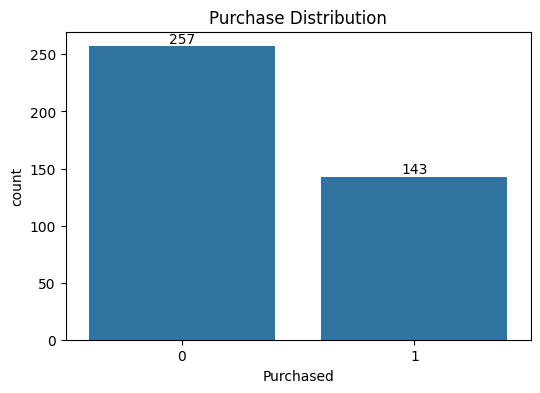

In [38]:
plt.figure(figsize=(6,4))
countplot = sns.countplot(x=df["Purchased"])
for i in countplot.containers:
    countplot.bar_label(i)
plt.title("Purchase Distribution")
plt.show()

In [39]:
X = df[["Gender", "Age", "EstimatedSalary"]]
y = df["Purchased"]

In [40]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Train/test shapes:
(320, 3) (80, 3) (320,) (80,)


In [42]:
model = LogisticRegression(n_jobs=-1)
model.fit(X_train, y_train)

LogisticRegression(n_jobs=-1)

In [43]:
y_pred = model.predict(X_test)

In [44]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[50  2]
 [ 7 21]]


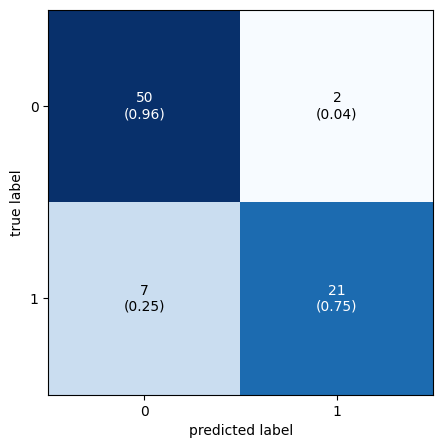

In [45]:
plot_confusion_matrix(conf_mat=cm, figsize=(5,5), show_normed=True)
plt.show()

In [46]:
print(f"\nTN value is {cm[0][0]}")
print(f"FP value is {cm[0][1]}")
print(f"FN value is {cm[1][0]}")
print(f"TP value is {cm[1][1]}")


TN value is 50
FP value is 2
FN value is 7
TP value is 21


In [47]:
print(f"\nAccuracy score is {accuracy_score(y_test, y_pred)}")
print(f"Error rate is {1-accuracy_score(y_test, y_pred)}")
print(f"Precision score is {precision_score(y_test, y_pred)}")
print(f"Recall score is {recall_score(y_test, y_pred)}")


Accuracy score is 0.8875
Error rate is 0.11250000000000004
Precision score is 0.9130434782608695
Recall score is 0.75


In [48]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80

